# Exploración Inicial de Datos: TCA Hospitality

TCA Hospitality forma parte de la oferta vertical de software hotelero de TCA, una empresa latinoamericana enfocada en soluciones tecnológicas especializadas para hospitalidad, retail y salud. En este notebook se construye una exploración inicial del dataset entregado en `./tablas_parquet`, apoyándose en los diccionarios de `./diccionario_datos`, con dos objetivos:

1. Entender la estructura, cobertura temporal y calidad básica de las tablas.
2. Preparar una base sólida para el análisis financiero y la detección de anomalías en una segunda fase.

El foco principal queda en `hottra` (transacciones), `hotvta` (ventas agregadas), `hothsp` (reservas / huéspedes) y `hotest` (estadísticas operativas).

In [1]:
from pathlib import Path
import re

import numpy as np
import pandas as pd
import pyarrow.parquet as pq
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)
plt.rcParams["figure.figsize"] = (14, 5)

BASE_DIR = Path.cwd().resolve()
if not (BASE_DIR / "tablas_parquet").exists():
    BASE_DIR = BASE_DIR.parent

DATA_DIR = BASE_DIR / "tablas_parquet"
DICT_DIR = BASE_DIR / "diccionario_datos"
TABLE_FILES = sorted(DATA_DIR.glob("*.parquet"))
TABLE_NAMES = [path.stem for path in TABLE_FILES]
CORE_TABLES = ["hottra", "hotvta", "hothsp", "hotest", "hothab", "hotcsm", "hotcag", "hotace"]

print(f"Base dir: {BASE_DIR}")
print(f"Tablas detectadas: {len(TABLE_NAMES)}")
print(TABLE_NAMES)

Base dir: /Users/adrianmateos/Documents/RetoOctavo
Tablas detectadas: 24
['hotace', 'hotcag', 'hotccs', 'hotcli', 'hotcmn', 'hotcsa', 'hotcse', 'hotcsm', 'hotctc', 'hotcth', 'hotcvt', 'hotedo', 'hotest', 'hotfbl', 'hothab', 'hothch', 'hothsp', 'hotreq', 'hotsce', 'hotstp', 'hottce', 'hottra', 'hottrj', 'hotvta']


## Utilidades

Se definen funciones para:

- Leer tablas parquet y convertir automáticamente columnas de fecha en formato `YYYYMMDD`.
- Resumir metadatos desde los diccionarios técnicos.
- Detectar discrepancias entre lo documentado en los diccionarios y las columnas realmente presentes en parquet.
- Construir un inventario compacto de todas las tablas disponibles.

In [2]:
DATE_MARKERS = ("fec", "fecha")


def clean_text(series: pd.Series) -> pd.Series:
    return series.fillna("").astype(str).str.strip().replace({"": "(blank)"})


def detect_date_columns(columns) -> list[str]:
    return [col for col in columns if any(marker in col.lower() for marker in DATE_MARKERS)]


def parse_yyyymmdd(series: pd.Series) -> pd.Series:
    cleaned = series.astype(str).str.strip()
    cleaned = cleaned.where(~cleaned.isin(["", "00000000", "None", "nan", "NaT"]))
    return pd.to_datetime(cleaned, format="%Y%m%d", errors="coerce")


def read_table(name: str, columns=None, parse_dates: bool = True) -> pd.DataFrame:
    df = pd.read_parquet(DATA_DIR / f"{name}.parquet", columns=columns)
    if parse_dates:
        for col in detect_date_columns(df.columns):
            df[col] = parse_yyyymmdd(df[col])
    return df


def read_dictionary_text(name: str) -> str:
    path = DICT_DIR / f"{name}.txt"
    if not path.exists():
        return ""
    return path.read_text(encoding="utf-8", errors="ignore")


def clean_comment_text(value: str) -> str:
    return value.replace("*/", "").strip()


def dictionary_summary(name: str) -> dict:
    text = read_dictionary_text(name)
    desc = re.search(r"DESCRIPCION:\s*(.+)", text)
    key = re.search(r"LLAVE[S]?:\s*(.+)", text)
    return {
        "tabla": name,
        "descripcion_diccionario": clean_comment_text(desc.group(1)) if desc else "",
        "llave_diccionario": clean_comment_text(key.group(1)) if key else "",
    }


def extract_dictionary_fields(name: str) -> pd.DataFrame:
    records = []
    for line in read_dictionary_text(name).splitlines():
        if "/*" not in line or "*/" not in line:
            continue
        stripped = line.strip()
        if stripped.startswith("/*"):
            continue
        left, right = stripped.split("/*", 1)
        tokens = left.strip().replace(";", "").split()
        if not tokens:
            continue
        field = tokens[-1].split("[")[0]
        if not re.fullmatch(r"[A-Za-z_][A-Za-z0-9_]*", field):
            continue
        records.append(
            {
                "field": field,
                "descripcion": clean_comment_text(right.split("*/", 1)[0]),
            }
        )
    return pd.DataFrame(records).drop_duplicates()


def table_inventory(path: Path) -> dict:
    parquet = pq.ParquetFile(path)
    schema_cols = parquet.schema_arrow.names
    date_cols = detect_date_columns(schema_cols)
    min_fecha = pd.NaT
    max_fecha = pd.NaT
    if date_cols:
        preview = pd.read_parquet(path, columns=date_cols[:4])
        parsed = [parse_yyyymmdd(preview[col]) for col in date_cols[:4]]
        parsed = pd.concat(parsed, axis=0).dropna()
        if not parsed.empty:
            min_fecha = parsed.min()
            max_fecha = parsed.max()
    summary = dictionary_summary(path.stem)
    return {
        "tabla": path.stem,
        "rows": parquet.metadata.num_rows,
        "cols": len(schema_cols),
        "file_mb": round(path.stat().st_size / 1024**2, 2),
        "date_cols": ", ".join(date_cols[:6]),
        "min_fecha": min_fecha,
        "max_fecha": max_fecha,
        **summary,
    }


inventory = pd.DataFrame([table_inventory(path) for path in TABLE_FILES]).sort_values(
    ["rows", "cols"], ascending=[False, False]
).reset_index(drop=True)

In [9]:
display(Markdown("## Inventario General de Tablas"))
display(inventory)

display(Markdown("## Diccionarios Clave"))
dictionary_df = pd.DataFrame([dictionary_summary(name) for name in CORE_TABLES])
display(dictionary_df)

display(Markdown("## Alineación entre Diccionario y Parquet"))
display(Markdown("Comparación indicativa: los diccionarios contienen estructuras anidadas y nomenclaturas heredadas, así que este cruce sirve como alerta de esquema, no como validación contractual exacta."))
schema_alignment = []
for name in CORE_TABLES:
    parquet_cols = set(pq.ParquetFile(DATA_DIR / f"{name}.parquet").schema_arrow.names)
    dict_fields_df = extract_dictionary_fields(name)
    dict_cols = set(dict_fields_df["field"]) if not dict_fields_df.empty else set()
    schema_alignment.append(
        {
            "tabla": name,
            "campos_parquet": len(parquet_cols),
            "campos_diccionario": len(dict_cols),
            "faltan_en_parquet": ", ".join(sorted(dict_cols - parquet_cols)),
            "extras_en_parquet": ", ".join(sorted(parquet_cols - dict_cols)),
        }
    )
schema_alignment_df = pd.DataFrame(schema_alignment)
display(schema_alignment_df)

hotvta_dict_fields = extract_dictionary_fields("hotvta")
if not hotvta_dict_fields.empty:
    display(Markdown("### Campos documentados para `hotvta`"))
    display(hotvta_dict_fields.head(20))

## Inventario General de Tablas

,tabla,rows,cols,file_mb,date_cols,min_fecha,max_fecha,descripcion_diccionario,llave_diccionario
0,hottra,1145526,43,27.03,t_fecha,2021-02-19,2026-03-11,Archivo de Transacciones,FOLIO_FECHA = t_folio + t_folio_ext + t_fecha +
1,hotvta,213912,43,4.96,fec_vta,2021-03-01,2027-01-02,Acumular Estadisticas de Venta por agencia y contrato,KEY = fec_vta + agencia + tpo_hab + contrato (UNICA)
2,hothsp,171669,167,19.96,"h_res_fec, h_fec_lld, h_fec_reg, h_fec_sda, h_fec_lim, h_ult_cam_fec",2019-08-07,2027-01-02,Almacenar toda informacion del Huesped referente a su,RESERVACION = h_res_cve
3,hotest,21265,21,0.18,est_fec,2021-02-19,2026-03-10,Archivo de Estadisticas.,TPOHAB_FECHA = tpo_hab + fec
4,hothch,8238,20,0.14,"h_fec_lld, h_fec_sda",2021-03-21,2027-01-02,Almacenar toda informacion de los Huespedes que comparten,RESERVACION = h_res_cve
5,hotfbl,3081,5,0.01,"fecha_ini_blo, fecha_blo",2025-08-23,2026-08-19,Archivo que mantiene Fecha de Bloqueo de las Habitaciones,NUM_HAB = num_hab + fecha_blo
6,hotcvt,2350,3,0.02,v_fec,2021-02-19,2026-03-10,Guarda los Tipos de Cambio Diarios de todas las Monedas,KEY = v_cve_mon + v_fec
7,hotcli,914,96,0.10,"c_mod_fec, c_fec_ult_vta, c_fec_ult_pag, c_fecha_corte, c_fec_alt, c_fec_mod_cred",NaT,NaT,Archivo de Clientes (Agencias),KEY = c_cve_cxc
8,hotedo,626,5,0.01,,NaT,NaT,Catalogo de Estados y Paises,KEY = e_cod
9,hottce,404,44,0.07,"fecha_alta, fecha_acti, fecha_esti, fecha_al_1, fecha_al_2, fecha_al_3",2021-04-24,2022-05-07,Transacciones de solicitudes para Control de Entregas,EVENTO: evento


## Diccionarios Clave

,tabla,descripcion_diccionario,llave_diccionario
0,hottra,Archivo de Transacciones,FOLIO_FECHA = t_folio + t_folio_ext + t_fecha +
1,hotvta,Acumular Estadisticas de Venta por agencia y contrato,KEY = fec_vta + agencia + tpo_hab + contrato (UNICA)
2,hothsp,Almacenar toda informacion del Huesped referente a su,RESERVACION = h_res_cve
3,hotest,Archivo de Estadisticas.,TPOHAB_FECHA = tpo_hab + fec
4,hothab,Almacenar la informacion referente a las Habitaciones del,KEY = c_tpo_hab + c_num_hab
5,hotcsm,Catalogo de Segmentos de Mercado.,KEY = seg_mer
6,hotcag,Archivo de Catalogos Generales,KEY = tipo + codigo
7,hotace,Catalogo de Avisos y Alertas para Control de Entregas,CODIGO: codigo


## Alineación entre Diccionario y Parquet

Comparación indicativa: los diccionarios contienen estructuras anidadas y nomenclaturas heredadas, así que este cruce sirve como alerta de esquema, no como validación contractual exacta.

,tabla,campos_parquet,campos_diccionario,faltan_en_parquet,extras_en_parquet
0,hottra,43,35,,"t_can_mto, t_num_per, t_numctapago, t_renta, t_tipo_cambio, t_tipo_trans, t_tra_cancelada, t_tra_mto"
1,hotvta,43,41,,"pres_ingr_hab, pres_tot_noch"
2,hothsp,167,142,"h_ori_sda, h_p_comision, h_tar_pro_1, h_tar_pro_2, mbo, num, struct, tpo","h_apa_fec_ini, h_apa_num_hab, h_apa_tpo_hab, h_apellido_m, h_apellido_p, h_cod_age_2, h_cod_age_fac, h_cod_cia, h_co..."
3,hotest,21,20,"buffer, i_buf","est_fec, ibuff, tpo_hab"
4,hothab,31,31,,
5,hotcsm,13,12,"agencia, canal, cod_renta, descrip, grupo, paquete, programa, recepcion, reservacion, seg_mer, tarifa0, tipo_tarifa","Codigo_Renta, Descripcion, Lleva_Agencia, Lleva_Canal, Lleva_Grupo, Lleva_Paquete, Lleva_Programa, Millas_Kms, Permi..."
6,hotcag,23,22,"amaLlaves, fin","ibuff, millas_kms, otros"
7,hotace,9,9,,


### Campos documentados para `hotvta`

,field,descripcion
0,fec_vta,FECHA DE VENTA AA-MM-DD
1,agencia,SEGMENTO DE MERCADO
2,tpo_hab,TIPO DE HABITACION
3,contrato,SEGMENTO ALTERNO
4,segmento,SEGMENTO DE MERCADO
5,seg_mer,SEGMENTO DE MERCADO
6,seg_alt,SEGMENTO ALTERNO
7,pais_canales,PAIS+EDO+CANAL+PROGRAMA+PAQUETE
8,pais_edo,PAIS + EDO
9,pais,PAIS


## Carga de Tablas Núcleo y Perfil Básico

Las siguientes tablas concentran la mayor parte del análisis posterior:

- `hottra`: transacciones individuales con montos, impuestos, propinas, cancelación y centro de consumo.
- `hotvta`: ventas agregadas por fecha, agencia, tipo de habitación y segmentos comerciales.
- `hothsp`: estado completo de reservaciones / huéspedes, incluyendo tarifa y fechas de estancia.
- `hotest`: estadísticas operativas por fecha y tipo de habitación.

In [4]:
hottra = read_table("hottra")
hotvta = read_table("hotvta")
hothsp = read_table("hothsp")
hotest = read_table("hotest")


def focus_quality(df: pd.DataFrame, name: str) -> dict:
    datetime_cols = [col for col in df.columns if pd.api.types.is_datetime64_any_dtype(df[col])]
    min_date = pd.NaT
    max_date = pd.NaT
    if datetime_cols:
        parsed = pd.concat([df[col] for col in datetime_cols], axis=0).dropna()
        if not parsed.empty:
            min_date = parsed.min()
            max_date = parsed.max()
    return {
        "tabla": name,
        "rows": len(df),
        "cols": len(df.columns),
        "pct_missing_cells": round(float(df.isna().mean().mean() * 100), 2),
        "min_fecha": min_date,
        "max_fecha": max_date,
    }


focus_quality_df = pd.DataFrame(
    [
        focus_quality(hottra, "hottra"),
        focus_quality(hotvta, "hotvta"),
        focus_quality(hothsp, "hothsp"),
        focus_quality(hotest, "hotest"),
    ]
)
display(focus_quality_df)

,tabla,rows,cols,pct_missing_cells,min_fecha,max_fecha
0,hottra,1145526,43,0.00,2021-02-19,2026-03-11
1,hotvta,213912,43,0.00,2021-03-01,2027-01-02
2,hothsp,171669,167,2.93,1963-07-15,2027-01-02
3,hotest,21265,21,0.00,2021-02-19,2026-03-10


## `hottra`: Transacciones y Primera Señal Financiera

,transacciones,monto_firmado
codigo,,
RENHAB,344113,7.354802e+08
DEPHAB,59256,4.286232e+08
CANXFA,10661,5.145201e+07
PROPTI,492168,3.901161e+07
DEPRES,3335,2.305388e+07
RENCOM,11032,7.709444e+06
SALANT,1864,7.194629e+06
CANCXC,2045,5.595704e+06
PEREXT,4874,5.082234e+06


,transacciones,monto_bruto,monto_firmado,canceladas,pct_canceladas,z_monto_firmado,flag_iqr
t_fecha,,,,,,,
2025-12-30,868,4970254.69,-1040223.83,2,0.002304,-5.046608,True
2022-12-30,908,3317582.56,-977906.18,78,0.085903,-4.761785,True
2023-12-26,992,4228435.51,-846303.89,22,0.022177,-4.160295,True
2025-12-31,858,2567562.76,946477.92,14,0.016317,4.033634,True
2022-12-26,903,3241843.64,-770556.44,70,0.077519,-3.814090,True
2025-12-26,927,4132053.00,-741889.74,36,0.038835,-3.683069,True
2024-03-28,1034,3105726.54,-724021.52,90,0.087041,-3.601402,True
2022-12-31,740,1241092.33,822047.13,70,0.094595,3.464922,True
2024-12-31,837,2209813.85,812014.41,80,0.095579,3.419067,True


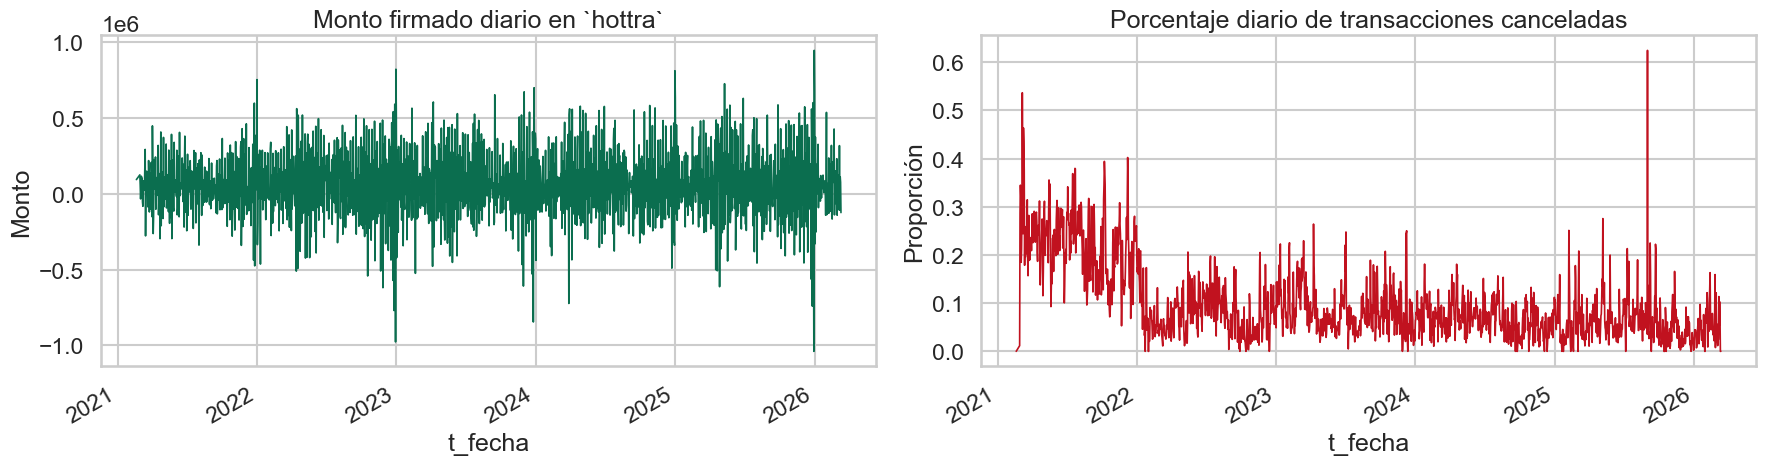

In [5]:
display(Markdown("## `hottra`: Transacciones y Primera Señal Financiera"))

hottra = hottra.copy()
hottra["codigo"] = clean_text(hottra["t_codigo"])
hottra["centro_consumo"] = clean_text(hottra["t_centro_consumo"])
hottra["carabo"] = clean_text(hottra["t_carabo"])
hottra["cancelada"] = clean_text(hottra["t_tra_cancelada"]).eq("1")
hottra["signo"] = np.where(hottra["carabo"].eq("0"), 1, -1)
componentes = [col for col in ["t_monto", "t_impuesto", "t_impuesto2", "t_propina"] if col in hottra.columns]
hottra["monto_total"] = hottra[componentes].fillna(0).sum(axis=1)
hottra["monto_firmado"] = hottra["signo"] * hottra["monto_total"]

hottra_daily = (
    hottra.dropna(subset=["t_fecha"])
    .groupby("t_fecha")
    .agg(
        transacciones=("codigo", "size"),
        monto_bruto=("monto_total", "sum"),
        monto_firmado=("monto_firmado", "sum"),
        canceladas=("cancelada", "sum"),
    )
    .sort_index()
)
hottra_daily["pct_canceladas"] = hottra_daily["canceladas"] / hottra_daily["transacciones"]
std_hottra = hottra_daily["monto_firmado"].std(ddof=0)
hottra_daily["z_monto_firmado"] = np.where(
    std_hottra > 0,
    (hottra_daily["monto_firmado"] - hottra_daily["monto_firmado"].mean()) / std_hottra,
    0,
)
q1 = hottra_daily["monto_firmado"].quantile(0.25)
q3 = hottra_daily["monto_firmado"].quantile(0.75)
iqr = q3 - q1
lim_inf = q1 - 1.5 * iqr
lim_sup = q3 + 1.5 * iqr
hottra_daily["flag_iqr"] = (hottra_daily["monto_firmado"] < lim_inf) | (hottra_daily["monto_firmado"] > lim_sup)

top_codigos = (
    hottra.groupby("codigo")
    .agg(transacciones=("codigo", "size"), monto_firmado=("monto_firmado", "sum"))
    .sort_values("monto_firmado", ascending=False)
    .head(15)
)
anomalias_hottra = hottra_daily[
    hottra_daily["flag_iqr"] | hottra_daily["z_monto_firmado"].abs().ge(3)
].sort_values("z_monto_firmado", key=lambda s: s.abs(), ascending=False)

display(top_codigos)
display(anomalias_hottra.head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
hottra_daily["monto_firmado"].plot(ax=axes[0], color="#0B6E4F", linewidth=1.2)
axes[0].set_title("Monto firmado diario en `hottra`")
axes[0].set_ylabel("Monto")

hottra_daily["pct_canceladas"].plot(ax=axes[1], color="#C1121F", linewidth=1.2)
axes[1].set_title("Porcentaje diario de transacciones canceladas")
axes[1].set_ylabel("Proporción")
plt.tight_layout()
plt.show()

## `hotvta`: Ventas Agregadas por Fecha, Agencia y Segmento

,noches,ingresos_habitacion
segmento_limpio,,
ONL255,83447,1.687810e+08
GPO410,60952,9.708554e+07
MAY330,42099,7.438626e+07
GSH650,40846,7.249987e+07
GPO405,37510,6.569389e+07
TRA125,15279,3.621850e+07
TRA120,10042,2.262538e+07
TRA101,6073,1.446804e+07
TRA110,6146,1.441123e+07


,noches,ingresos_habitacion
agencia_limpia,,
1BKINGMX,23359,52798863.42
GSHSOC,23047,42217524.84
1IMAGDL,23576,38958679.29
1PRIMX,22233,38037336.56
DIRHTL,16102,37695184.99
GRDIHT,19350,34545476.36
1DESPMXP,16579,29727535.54
GSHINV,16388,27900640.20
1EXPEDMEC,10807,26795823.88


,noches_vendidas,ingresos_habitacion,otros_ingresos,ingresos_extras,impuestos,entradas,salidas,ingreso_promedio_por_noche,z_ingresos
fec_vta,,,,,,,,,
2024-12-31,269,863513.78,0.0,0.0,0.0,40,14,3210.088401,4.015368
2025-12-31,268,825463.84,0.0,0.0,0.0,42,16,3080.088955,3.756796
2026-01-01,254,778898.63,0.0,0.0,0.0,37,51,3066.530039,3.440357
2024-12-30,243,776697.35,0.0,0.0,0.0,126,41,3196.285391,3.425398
2025-12-30,242,757119.35,0.0,0.0,0.0,178,71,3128.592355,3.292353
2024-12-28,267,744155.70,0.0,0.0,0.0,50,46,2787.100000,3.204258
2021-12-31,241,744062.16,0.0,0.0,0.0,63,38,3087.394855,3.203622
2025-01-01,254,743519.77,0.0,0.0,0.0,51,66,2927.243189,3.199936
2025-12-27,258,720501.37,0.0,0.0,0.0,49,32,2792.640969,3.043512


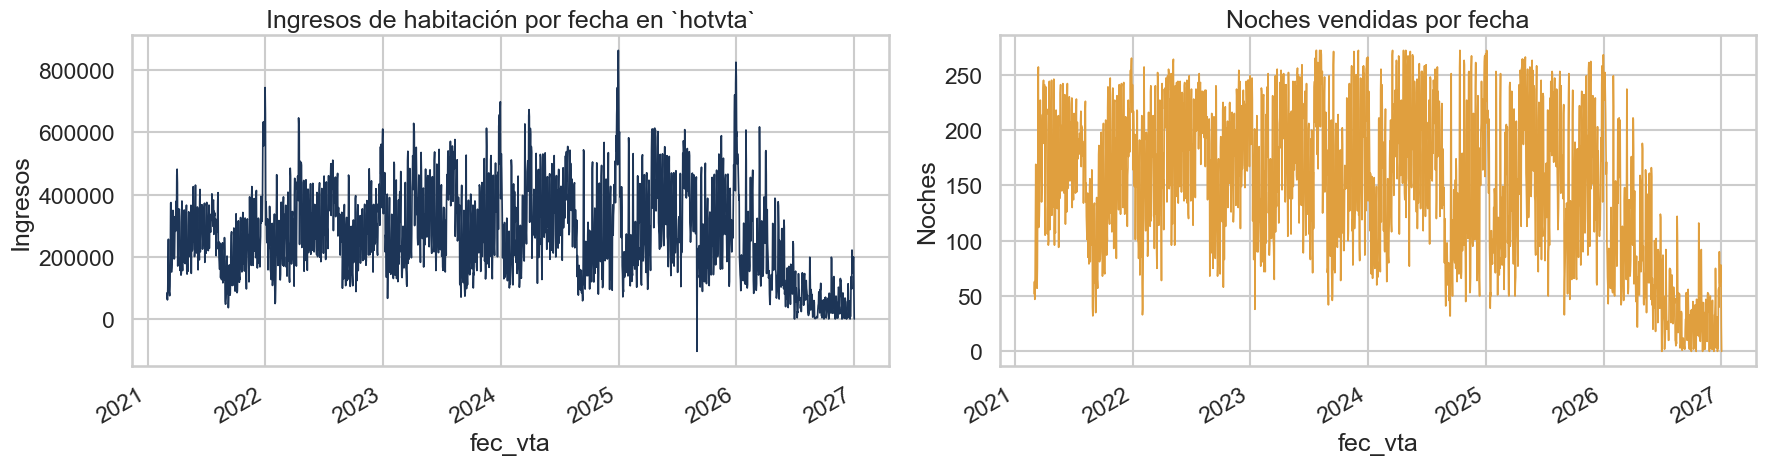

In [6]:
display(Markdown("## `hotvta`: Ventas Agregadas por Fecha, Agencia y Segmento"))

hotvta = hotvta.copy()
hotvta["segmento_limpio"] = clean_text(hotvta["segmento"])
hotvta["agencia_limpia"] = clean_text(hotvta["agencia"])
hotvta["seg_mer_limpio"] = clean_text(hotvta["seg_mer"])
hotvta["seg_alt_limpio"] = clean_text(hotvta["seg_alt"])

hotvta_daily = (
    hotvta.dropna(subset=["fec_vta"])
    .groupby("fec_vta")
    .agg(
        noches_vendidas=("cto_noc", "sum"),
        ingresos_habitacion=("cto_ing", "sum"),
        otros_ingresos=("otr_ing", "sum"),
        ingresos_extras=("ing_extras", "sum"),
        impuestos=("ing_impuestos", "sum"),
        entradas=("cto_lld", "sum"),
        salidas=("cto_sda", "sum"),
    )
    .sort_index()
)
hotvta_daily["ingreso_promedio_por_noche"] = hotvta_daily["ingresos_habitacion"] / hotvta_daily["noches_vendidas"].replace(0, np.nan)
std_hotvta = hotvta_daily["ingresos_habitacion"].std(ddof=0)
hotvta_daily["z_ingresos"] = np.where(
    std_hotvta > 0,
    (hotvta_daily["ingresos_habitacion"] - hotvta_daily["ingresos_habitacion"].mean()) / std_hotvta,
    0,
)

top_segmentos = (
    hotvta.groupby("segmento_limpio")
    .agg(noches=("cto_noc", "sum"), ingresos_habitacion=("cto_ing", "sum"))
    .sort_values("ingresos_habitacion", ascending=False)
    .head(15)
)
top_agencias = (
    hotvta.groupby("agencia_limpia")
    .agg(noches=("cto_noc", "sum"), ingresos_habitacion=("cto_ing", "sum"))
    .sort_values("ingresos_habitacion", ascending=False)
    .head(15)
)
anomalias_hotvta = hotvta_daily[hotvta_daily["z_ingresos"].abs().ge(3)].sort_values(
    "z_ingresos", key=lambda s: s.abs(), ascending=False
)

display(top_segmentos)
display(top_agencias)
display(anomalias_hotvta.head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
hotvta_daily["ingresos_habitacion"].plot(ax=axes[0], color="#1D3557", linewidth=1.2)
axes[0].set_title("Ingresos de habitación por fecha en `hotvta`")
axes[0].set_ylabel("Ingresos")

hotvta_daily["noches_vendidas"].plot(ax=axes[1], color="#E09F3E", linewidth=1.2)
axes[1].set_title("Noches vendidas por fecha")
axes[1].set_ylabel("Noches")
plt.tight_layout()
plt.show()

## `hothsp`: Calidad de Reservaciones y Variables Operativas

,rows
status,
Salida,122855
Reservación cancelada,41963
No show,4109
Reservación / registro,2487
Reservación en transición,165
En casa,69
(blank),9
04,9
Preregistro,3


,rows
tipo_hab,
C2D,57988
C1K,46270
C4K,12636
C6D,11336
C5D,10455
C3K,10359
B1K,9036
A1B,5601
C1I,4095


,h_res_cve,status_desc,h_res_fec,h_fec_lld,h_fec_sda,h_tfa,estancia_calculada,anticipacion_reserva
1677,I 705 1,Salida,2021-03-01,2021-02-28,2021-03-02,1747.00,2,-1
1700,I 676 2,Reservación en transición,2021-03-01,2021-02-28,2021-02-28,865.78,0,-1
2677,I 1662 1,Salida,2021-03-07,2021-03-06,2021-03-07,500.00,1,-1
2747,I 1659 1,Salida,2021-03-07,2021-03-06,2021-03-08,1991.00,2,-1
3477,I 2257 1,Salida,2021-03-12,2021-03-11,2021-03-12,2074.00,1,-1
4073,I 4448 1,Salida,2021-04-03,2021-04-08,2021-04-10,-5050.00,2,5
4144,I 3006 1,Salida,2021-03-20,2021-03-19,2021-03-20,2204.95,1,-1
4569,I 2661 2,Salida,2021-03-20,2021-03-19,2021-03-20,1335.50,1,-1
4578,I 3006 2,Salida,2021-03-20,2021-03-19,2021-03-20,1653.71,1,-1
4582,I 3006 3,Salida,2021-03-20,2021-03-19,2021-03-20,1653.71,1,-1


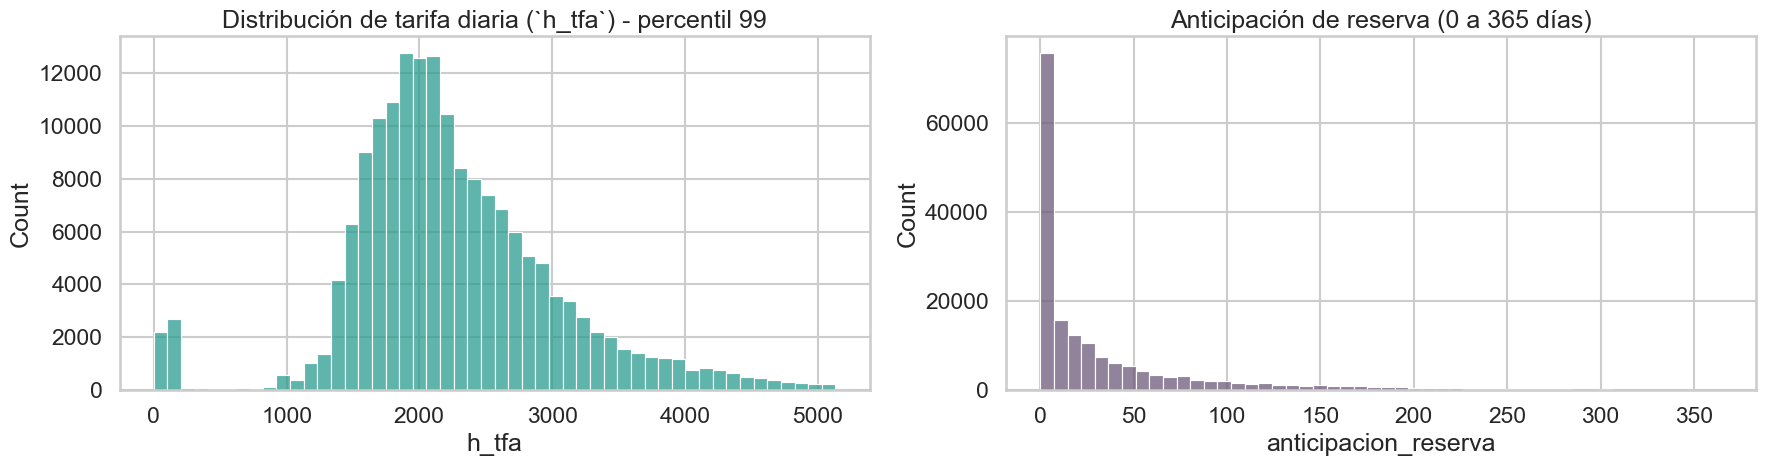

In [7]:
display(Markdown("## `hothsp`: Calidad de Reservaciones y Variables Operativas"))

STATUS_MAP = {
    "00": "Reservación / registro",
    "01": "Reservación cancelada",
    "02": "No show",
    "03": "Reservación en transición",
    "08": "Registro en tránsito",
    "09": "Preregistro",
    "10": "En casa",
    "50": "Salida",
}

hothsp = hothsp.copy()
hothsp["status"] = clean_text(hothsp["h_status"])
hothsp["status_desc"] = hothsp["status"].map(STATUS_MAP).fillna(hothsp["status"])
hothsp["tipo_hab"] = clean_text(hothsp["h_tpo_hab"])
hothsp["segmento"] = clean_text(hothsp["h_seg_mer"])
hothsp["agencia"] = clean_text(hothsp["h_cod_age"])
hothsp["estancia_calculada"] = (hothsp["h_fec_sda"] - hothsp["h_fec_lld"]).dt.days
hothsp["anticipacion_reserva"] = (hothsp["h_fec_lld"] - hothsp["h_res_fec"]).dt.days

status_counts = hothsp["status_desc"].value_counts(dropna=False).rename_axis("status").to_frame("rows")
top_tipos_hab = hothsp["tipo_hab"].value_counts().head(15).rename_axis("tipo_hab").to_frame("rows")
quality_flags = hothsp[
    (hothsp["estancia_calculada"] < 0)
    | (hothsp["anticipacion_reserva"] < 0)
    | (hothsp["h_tfa"] < 0)
][
    [
        "h_res_cve",
        "status_desc",
        "h_res_fec",
        "h_fec_lld",
        "h_fec_sda",
        "h_tfa",
        "estancia_calculada",
        "anticipacion_reserva",
    ]
].head(20)

display(status_counts)
display(top_tipos_hab)
display(quality_flags)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
sns.histplot(
    data=hothsp[hothsp["h_tfa"].between(0, hothsp["h_tfa"].quantile(0.99))],
    x="h_tfa",
    bins=50,
    ax=axes[0],
    color="#2A9D8F",
)
axes[0].set_title("Distribución de tarifa diaria (`h_tfa`) - percentil 99")

sns.histplot(
    data=hothsp[hothsp["anticipacion_reserva"].between(0, 365)],
    x="anticipacion_reserva",
    bins=50,
    ax=axes[1],
    color="#6D597A",
)
axes[1].set_title("Anticipación de reserva (0 a 365 días)")
plt.tight_layout()
plt.show()

## `hotest`: Estadística Operativa Diaria

/var/folders/lv/34x2z89s3s3bys5fzpv8k45c0000gn/T/ipykernel_71946/387442670.py:21: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  hotest_valid.assign(peso=hotest_valid["cto_tot"].where(hotest_valid["cto_tot"] > 0, 0))


,count,mean,std,min,25%,50%,75%,max
cuartos_totales,1839.0,271.704187,8.967572,0.0,272.000000,272.000000,272.000000,272.000000
fuera_servicio,1839.0,22.098967,18.467747,0.0,8.000000,19.000000,31.000000,99.000000
vacias_limpias,1839.0,56.907558,45.680314,0.0,17.000000,47.000000,88.000000,197.000000
vacias_sucias,1839.0,8.057096,15.896992,0.0,2.000000,4.000000,7.000000,272.000000
cancelaciones,1839.0,22.468733,16.218616,0.0,11.000000,18.000000,30.000000,126.000000
no_show,1839.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
entradas,1839.0,66.660685,40.402277,0.0,35.000000,56.000000,91.500000,214.000000
salidas,1839.0,66.671561,49.795630,0.0,32.000000,51.000000,82.000000,249.000000
walk_in,1839.0,0.988581,1.828436,0.0,0.000000,0.000000,1.000000,22.000000
tarifa_prom_ponderada,1837.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000


,cuartos_totales,fuera_servicio,vacias_limpias,vacias_sucias,cancelaciones,no_show,entradas,salidas,walk_in,tarifa_prom_ponderada,ratio_cancelacion,ratio_no_show
est_fec,,,,,,,,,,,,
2024-11-16,272,4,8,3,126,0,153,23,0,0.0,0.463235,0.0
2022-04-14,272,17,2,1,112,0,162,117,0,0.0,0.411765,0.0
2024-12-23,272,8,79,11,109,0,123,114,0,0.0,0.400735,0.0
2023-12-23,272,0,89,4,103,0,135,46,1,0.0,0.378676,0.0
2021-12-26,272,7,7,0,102,0,139,167,2,0.0,0.375000,0.0
2024-06-14,272,10,24,4,97,0,138,69,0,0.0,0.356618,0.0
2022-12-26,272,20,4,2,96,0,171,141,1,0.0,0.352941,0.0
2024-12-13,272,10,78,1,90,0,145,17,0,0.0,0.330882,0.0
2024-09-14,272,3,22,4,89,0,149,12,0,0.0,0.327206,0.0


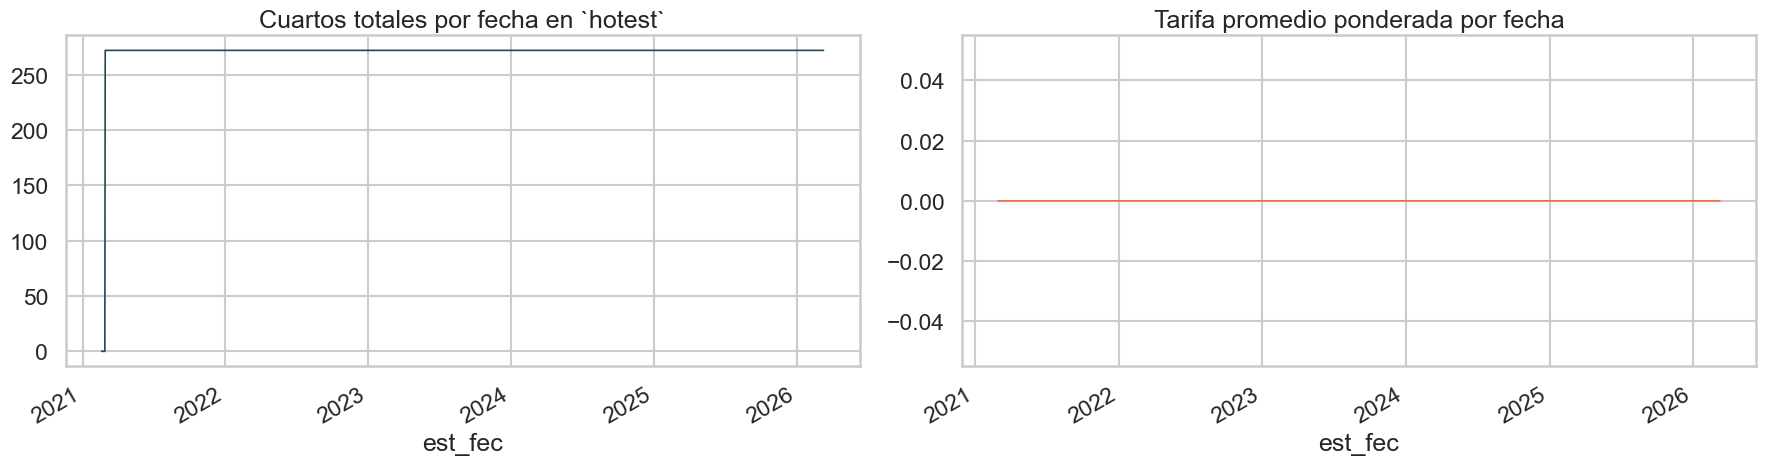

## Hallazgos Iniciales
- `hottra` cubre del 2021-02-19 al 2026-03-11 con 1,145,526 transacciones.
- `hotvta` cubre del 2021-03-01 al 2027-01-02 con 213,912 registros agregados.
- `hothsp` cubre llegadas del 2021-02-26 al 2026-12-31 y concentra estatus `Salida` como estado dominante.
- `hotest` contiene 21,254 filas con fecha válida; existen 11 filas sin fecha que conviene revisar.
- Hay diferencias entre diccionario y parquet, especialmente en `hotvta`, por lo que conviene validar el esquema operativo antes de modelar métricas financieras finales.

In [8]:
display(Markdown("## `hotest`: Estadística Operativa Diaria"))

hotest_valid = hotest.dropna(subset=["est_fec"]).copy()
hotest_daily = (
    hotest_valid.groupby("est_fec")
    .agg(
        cuartos_totales=("cto_tot", "sum"),
        fuera_servicio=("cto_fs", "sum"),
        vacias_limpias=("cto_va_l", "sum"),
        vacias_sucias=("cto_va_s", "sum"),
        cancelaciones=("cto_cancel", "sum"),
        no_show=("cto_no_show", "sum"),
        entradas=("cto_entrada", "sum"),
        salidas=("cto_salida", "sum"),
        walk_in=("cto_walk_inn", "sum"),
    )
    .sort_index()
)

tarifa_ponderada = (
    hotest_valid.assign(peso=hotest_valid["cto_tot"].where(hotest_valid["cto_tot"] > 0, 0))
    .groupby("est_fec")
    .apply(lambda x: np.average(x["tarifa_prom"], weights=x["peso"]) if x["peso"].sum() > 0 else np.nan)
    .rename("tarifa_prom_ponderada")
)
hotest_daily = hotest_daily.join(tarifa_ponderada)
hotest_daily["ratio_cancelacion"] = hotest_daily["cancelaciones"] / hotest_daily["cuartos_totales"].replace(0, np.nan)
hotest_daily["ratio_no_show"] = hotest_daily["no_show"] / hotest_daily["cuartos_totales"].replace(0, np.nan)

display(hotest_daily.describe().T)
display(hotest_daily.sort_values("ratio_cancelacion", ascending=False).head(15))

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
hotest_daily["cuartos_totales"].plot(ax=axes[0], color="#264653", linewidth=1.2)
axes[0].set_title("Cuartos totales por fecha en `hotest`")

hotest_daily["tarifa_prom_ponderada"].plot(ax=axes[1], color="#E76F51", linewidth=1.2)
axes[1].set_title("Tarifa promedio ponderada por fecha")
plt.tight_layout()
plt.show()

hallazgos = [
    f"- `hottra` cubre del {hottra['t_fecha'].min().date()} al {hottra['t_fecha'].max().date()} con {len(hottra):,} transacciones.",
    f"- `hotvta` cubre del {hotvta['fec_vta'].min().date()} al {hotvta['fec_vta'].max().date()} con {len(hotvta):,} registros agregados.",
    f"- `hothsp` cubre llegadas del {hothsp['h_fec_lld'].min().date()} al {hothsp['h_fec_lld'].max().date()} y concentra estatus `Salida` como estado dominante.",
    f"- `hotest` contiene {hotest['est_fec'].notna().sum():,} filas con fecha válida; existen {hotest['est_fec'].isna().sum():,} filas sin fecha que conviene revisar.",
    "- Hay diferencias entre diccionario y parquet, especialmente en `hotvta`, por lo que conviene validar el esquema operativo antes de modelar métricas financieras finales.",
]
display(Markdown("## Hallazgos Iniciales\n" + "\n".join(hallazgos)))

## Siguientes Pasos

Con esta exploración inicial ya es razonable pasar a una segunda fase centrada en anomalías financieras. La siguiente iteración puede enfocarse en:

1. Consolidar un calendario diario unificado entre `hottra`, `hotvta` y `hotest`.
2. Separar ingresos por concepto (`RENHAB`, `PROPTI`, depósitos, propinas, pagos, cancelaciones).
3. Construir reglas y modelos de anomalía por fecha, segmento, agencia, tipo de habitación y centro de consumo.
4. Contrastar montos agregados de ventas contra transacciones operativas para detectar descuadres.